<a href="https://colab.research.google.com/github/Lexuanthangutc/Cell-Detection/blob/main/PSPNET_Cell_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install -q torchmetrics
!pip3 install -q segmentation-models-pytorch
!pip3 install -q albumentations

# Connect Google Drive

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Packages

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageColor
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchmetrics
from torchmetrics import Dice, JaccardIndex
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor


import os
from tqdm import tqdm
from glob import glob # read and close image in folder


/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.18 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Preprocessing

In [28]:
Data_dir = "../input/"
images_dir = "../input/P01_images"
masks_dir = "../input/P01_masks"

CELL_CLASSES = [
    "Marcophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris",
    "Basophil",
]

trainsize = 256
train_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.HorizontalFlip(),
    # A.RandomBrightnessContrast(),
    A.Blur(),
    A.Sharpen(),
    # A.RGBShift(),
    A.CoarseDropout(),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

# Define color to class index mapping
label_colors = {
    (28, 230, 255): 1,  # Macrophage/Monocyte
    (255, 52, 255): 2,  # Neutrophil
    (255, 74, 70): 3,  # Eosinophil
    (0, 137, 65): 4,  # Lymphocyte
    (0, 111, 166): 5,  # Unknown cell/Debris
    (163, 0, 89): 6   # Basophil
}


# Dataset

In [29]:
class CellDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        """
        Args:
            images_dir (string): Path to the directory containing images.
            masks_dir (string): Path to the directory containing corresponding masks.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.images)

    def __getitem__(self, idx):
        """
        Generate one sample of data.
        """
        img_name = self.images[idx]
        mask_name = self.masks[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        mask = Image.open(mask_path).convert('RGB')

        # convert mask colors to classes
        mask = self.convert_mask(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image.float(), mask.long()

    def convert_mask(self, mask):
        """Convert RGB mask to a class map."""
        mask_array = np.array(mask)
        class_map = np.zeros(mask_array.shape[:2], dtype=np.int32)

        for color, class_id in label_colors.items():
            matches = (mask_array == color).all(axis=-1)
            class_map[matches] = class_id

        return class_map

In [30]:
# Initialize dataset
dataset = CellDataset(images_dir,masks_dir,transform=train_transform)

In [31]:
image,mask = dataset.__getitem__(1)

In [32]:
mask.shape

torch.Size([256, 256])

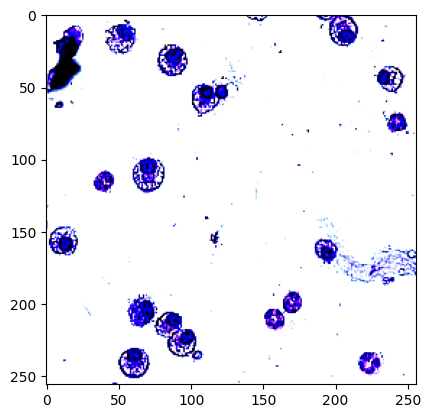

In [33]:
plt.imshow(image.permute(1,2,0).cpu())

In [34]:
mask.unique()

tensor([0, 1, 2, 4, 5])

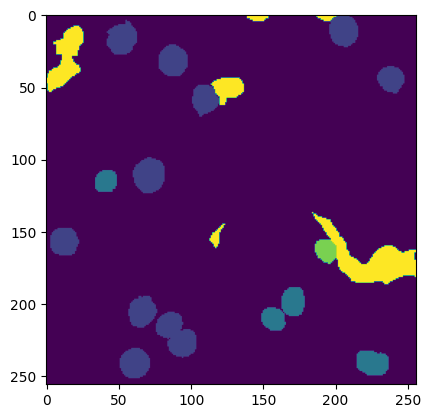

In [35]:
plt.imshow(mask.cpu())

In [36]:
def tensor_to_np(tensor):
    # Make sure the tensor is on the CPU and convert to NumPy
    return tensor.detach().cpu().numpy()

def np_to_tensor(array):
    # Convert a NumPy array back to PyTorch tensor
    return torch.tensor(array).float()

def inverse_norm(image):
    # Define the inverse transformation using Albumentations
    invTrans = A.Compose([
        A.Normalize(mean=[0., 0., 0.], std=[1/0.229, 1/0.224, 1/0.225], max_pixel_value=1.0),
        A.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.], max_pixel_value=1.0),
    ])

    # Example usage:
    # Assuming 'tensor_image' is your normalized image tensor
    tensor_image_np = tensor_to_np(image)  # Convert tensor to numpy array
    tensor_image_np = np.transpose(tensor_image_np, (1, 2, 0))  # CHW to HWC for Albumentations

    # Apply the inverse transformation
    inv_img_np = invTrans(image=tensor_image_np)['image']
    inv_img_np = np.transpose(inv_img_np, (2, 0, 1))  # HWC back to CHW for PyTorch

    # Convert back to tensor
    inv_img_tensor = np_to_tensor(inv_img_np)
    return inv_img_tensor


torch.Size([3, 256, 256]) torch.Size([256, 256])
tensor([0, 1, 2, 3, 5])
tensor([[[0.8784, 0.9020, 0.8549,  ..., 0.9490, 0.9176, 0.9098],
         [0.8314, 0.9020, 0.8980,  ..., 0.6706, 0.7490, 0.9412],
         [0.8941, 0.8980, 0.8902,  ..., 0.5098, 0.5647, 0.9451],
         ...,
         [0.8902, 0.8980, 0.9020,  ..., 0.3137, 0.3294, 0.3294],
         [0.8980, 0.8980, 0.8941,  ..., 0.2941, 0.2745, 0.2941],
         [0.9059, 0.9059, 0.8980,  ..., 0.4039, 0.3098, 0.3137]],

        [[0.8627, 0.8706, 0.8353,  ..., 0.8902, 0.8941, 0.8863],
         [0.8157, 0.8745, 0.8667,  ..., 0.6039, 0.7020, 0.9020],
         [0.8706, 0.8745, 0.8627,  ..., 0.4588, 0.5059, 0.8745],
         ...,
         [0.8784, 0.8863, 0.8784,  ..., 0.1294, 0.1294, 0.1294],
         [0.8745, 0.8745, 0.8824,  ..., 0.1451, 0.1137, 0.1216],
         [0.8824, 0.8824, 0.8863,  ..., 0.2510, 0.1765, 0.1686]],

        [[0.9216, 0.9333, 0.9098,  ..., 0.9765, 0.9451, 0.9333],
         [0.8627, 0.9255, 0.9294,  ..., 0.8078, 0.

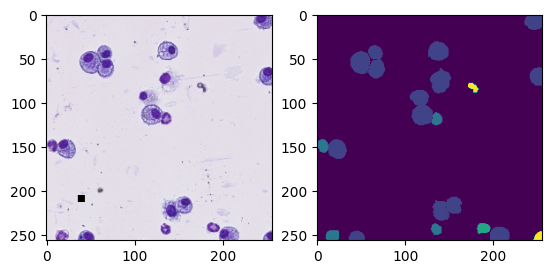

In [37]:
train_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)
image, mask = train_dataset.__getitem__(10)

print(image.shape, mask.shape)
print(mask.unique())
inv_img_tensor = inverse_norm(image)
print(inv_img_tensor)
plt.subplot(1,2,1)
plt.imshow(inv_img_tensor.permute(1,2,0))
plt.subplot(1,2,2)
plt.imshow(mask)
plt.show()

# Model

## UNet

In [38]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=7,                      # model output channels (number of classes in your dataset)
)

In [39]:
BATCH_SIZE = 4
n_workers = 4
train_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers = n_workers)

In [40]:
train_loader.dataset[1][0]

tensor([[[1.7865, 1.7694, 1.7694,  ..., 1.7865, 1.7523, 1.8037],
         [1.7694, 1.7865, 1.7865,  ..., 1.7865, 1.7352, 1.7865],
         [1.7865, 1.8037, 1.8379,  ..., 1.7694, 1.7694, 1.7865],
         ...,
         [1.8208, 1.8208, 1.7865,  ..., 1.7865, 1.7865, 1.7523],
         [1.7865, 1.7865, 1.7865,  ..., 1.7523, 1.7865, 1.8037],
         [1.7865, 1.7865, 1.7694,  ..., 1.7523, 1.7865, 1.8037]],

        [[1.8158, 1.7983, 1.8333,  ..., 1.8683, 1.8158, 1.8859],
         [1.7983, 1.8158, 1.8508,  ..., 1.8508, 1.7983, 1.8683],
         [1.8158, 1.8333, 1.8508,  ..., 1.8158, 1.8333, 1.8508],
         ...,
         [1.8859, 1.8859, 1.9034,  ..., 1.9034, 1.8683, 1.8859],
         [1.9034, 1.9034, 1.9034,  ..., 1.9034, 1.8508, 1.8683],
         [1.9034, 1.9034, 1.8859,  ..., 1.9034, 1.8508, 1.8683]],

        [[2.2566, 2.2391, 2.2566,  ..., 2.2217, 2.2391, 2.2391],
         [2.2391, 2.2566, 2.2740,  ..., 2.2914, 2.2217, 2.2217],
         [2.2566, 2.2740, 2.2566,  ..., 2.2217, 2.2217, 2.

In [41]:
image_size = 256
x = torch.rand(4,3,image_size, image_size).float()

In [42]:
image_size = 256
# model = UNet(classes=7)
x = torch.rand(4,3,image_size, image_size).float()
y = torch.ones(4,image_size,image_size).long()

a1 = model(x)
print(a1.shape)

torch.Size([4, 7, 256, 256])


# Metrics

In [43]:
class AverageMetric(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val=0
        self.avg=0
        self.sum=0
        self.count=0

    def update(self, val, n=1):
        self.val = val
        self.sum += val*n
        self.count += n
        self.avg = self.sum / self.count


def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [47]:

#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
batch_size = 8

n_workers = 4
print("number of workers=", n_workers)
print(device)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers = n_workers)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers = n_workers)

#model
num_classes = 7
# model = PSPNet(classes=num_classes)
model.to(device)

#loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 100

#metrics
dice_fn = torchmetrics.Dice(num_classes=num_classes, average="macro").to(device)
# iou_fn = intersectionAndUnionGPU().to(device)
acc_fn = torchmetrics.Accuracy(num_classes=num_classes, task="multiclass").to(device)

# metric
acc_metric = AverageMetric()
dice_metric = AverageMetric()
intersection_metric = AverageMetric()
union_metric = AverageMetric()
target_metric = AverageMetric()
train_loss_metric = AverageMetric()

cuda
number of workers= 4
cuda


# Training

In [50]:
for epoch in range(num_epochs):
    acc_metric.reset()
    # dice_metric.reset()
    intersection_metric.reset()
    union_metric.reset()
    target_metric.reset()
    train_loss_metric.reset()

    model.train()
    for batch_id, (x, y) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        n = x.shape[0]

        x = x.to(device).float() # B, C, H, W
        y = y.to(device).long() # B, H, W
#         print(x.is_cuda, y.is_cuda)
#         print("Model device:", next(model.parameters()).device)  # Print device of model weights
#         print("Input device:", x.device)  # Print device of input tensor
#         print("Label device:", y.device)  # Print device of label tensor

        yhat_mask  = model(x) # B,C,H,W
        # Calculate the loss (main loss is CrossEntropy)
        main_loss = criterion(yhat_mask, y)
        loss = main_loss  # You can include ax_loss if you have auxiliary outputs
        
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            yhat_mask = yhat_mask.argmax(dim=1).squeeze() # B,C,H,W -> # B,1,H,W -> # B,H,W
            # print(yhat_mask.shape, y.shape)
            # dice_score = dice_fn(yhat_mask,y.long())
            # iou_score = iou_fn(yhat_mask, y.long())
            intersection, union, target = intersectionAndUnionGPU(yhat_mask.float(), y.float(),6)
            accuracy = acc_fn(yhat_mask, y.long())

            # Update metrics
            acc_metric.update(accuracy.item(), n)
            intersection_metric.update(intersection.sum().item())
            union_metric.update(union.sum().item())
            target_metric.update(target.sum().item())
            train_loss_metric.update(loss.item(), n)
    with torch.no_grad():
        # Calculate per-class IoU and Dice coefficient
        iou_class = intersection_metric.sum / (union_metric.sum + 1e-10)
        dice_class = (2 * intersection_metric.sum) / (intersection_metric.sum + union_metric.sum + 1e-10)
        
        mIoU = torch.mean(torch.tensor(iou_class))
        mDice = torch.mean(torch.tensor(dice_class))

    print("Epoch {}: train_loss = {}, accuracy = {}, mIoU = {}, mDice = {}".format(
        epoch, train_loss_metric.avg, acc_metric.avg, mIoU, mDice
    ))

100%|██████████| 12/12 [00:10<00:00,  1.19it/s]


Epoch 0: train_loss = 1.8332335293947994, accuracy = 0.3224717024918441, mIoU = 0.2399696558713913, mDice = 0.3870573043823242


100%|██████████| 12/12 [00:09<00:00,  1.29it/s]


Epoch 1: train_loss = 1.6613304366122235, accuracy = 0.5953082416083787, mIoU = 0.47661906480789185, mDice = 0.6455545425415039


100%|██████████| 12/12 [00:09<00:00,  1.28it/s]


...

Epoch 97: train_loss = 0.13919173230181683, accuracy = 0.9617136854391831, mIoU = 0.9262509346008301, mDice = 0.9617136716842651


100%|██████████| 12/12 [00:09<00:00,  1.30it/s]


Epoch 98: train_loss = 0.13473703065416315, accuracy = 0.961363068648747, mIoU = 0.9256007075309753, mDice = 0.9613630771636963


100%|██████████| 12/12 [00:09<00:00,  1.30it/s]

Epoch 99: train_loss = 0.1328790661070373, accuracy = 0.9621789959760813, mIoU = 0.9271146059036255, mDice = 0.9621790051460266


torch.Size([1, 256, 256])
torch.Size([1, 7, 256, 256])
torch.Size([1, 256, 256])


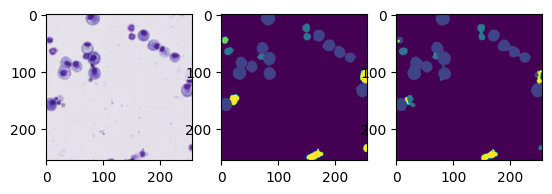

In [62]:
import random
idx = random.randint(0,90)
def visualization_pascalvoc(model, idx):
    model.eval()
    with torch.no_grad():
        x, y = train_dataset.__getitem__(idx) # get x: (C, H , W) , y: (H, W)
#         print(x.shape ,y.shape) # (C, H , W) - > (B, C, H, W) -> model
        x = x.to(device).float().unsqueeze(0) # convert x: (C, H , W) -> (1, C, H, W) vi model need Batch at first
        y = y.to(device).long().unsqueeze(0) # convert x: (C, H , W) -> (1, C, H, W) vi model need Batch at first
        print(y.shape)
        yhat = model(x) # input x: (1, C, H, W) and output y: (1, C, H , W)
        print(yhat.shape)
        yhat_mask = yhat.argmax(dim=1) # convert (1, C, H , W) -> (C, H , W)
        print(yhat_mask.shape)
        inv_img_tensor = inverse_norm(x.squeeze()) # x: (1, C, H, W) -> (C, H, W)
#         color_mask_prediction = np.zeros((*yhat_mask.shape,3))
#         for i, color in enumerate(VOC_COLORMAP):
#             color_mask_prediction[yhat_mask.cpu()==i] = np.array(color) # pixel 10(class10) -> [64, 128, 0]

#         color_mask_true = np.zeros((*yhat.shape,3))
#         for i, color in enumerate(VOC_COLORMAP):
#             color_mask_true[yhat.cpu()==i] = np.array(color) # pixel 10(class10) -> [64, 128, 0]
        # draw, x, y, yhat_mask
        plt.subplot(1,3,1)
        plt.imshow(inv_img_tensor.permute(1,2,0).cpu())
        plt.subplot(1,3,2)
        plt.imshow(y.squeeze().cpu())
        plt.subplot(1,3,3)
        plt.imshow(yhat_mask.cpu().permute(1,2,0))
        plt.show()

visualization_pascalvoc(model, idx)